# 로지스틱 회귀
## 가. 기본 개념
### 1. 이름은 회귀, 목적은 분류 : 선형 회귀 모델을 바탕으로 하지만, 최종 목적은 분류(Classification)를 수행하는 알고리즘
### 2. 확률값으로의 변환 : 선형 회귀의 연속적인 출력값(양수/음수)을 시그모이드(Sigmoid) 함수에 통과시켜 0과 1 사이의 확률값으로 압축 변환
### 3. 확률 기반 예측의 장점 : 단순히 클래스 범주만 판단하는 것이 아니라 "A 클래스일 확률이 95%"와 같은 확률적 정보를 제공하므로 유연한 의사결정이 가능

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## 나. 시그모이드(Sigmoid) 함수
### 1. 수식
  * $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
### 2. 입력값과 출력 확률의 관계 :
#### 가) $z \rightarrow -\infty$ 일 때 : $\sigma(z) \rightarrow 0$
#### 나) $z = 0$ 일 때 : $\sigma(z) = 0.5$ (결정 경계, Decision Boundary)
#### 다) 클래스 확률 계산 : 특정 샘플이 A 클래스일 확률이 $P$라면, B 클래스일 확률은 $1 - P$

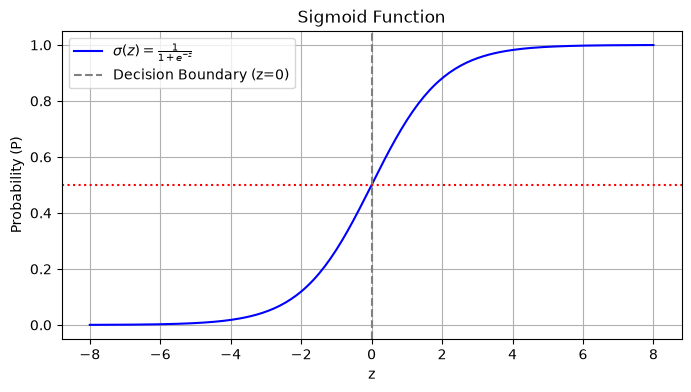

In [2]:
# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -8부터 8까지의 입력값 생성
z = np.linspace(-8, 8, 200)
phi_z = sigmoid(z)

# 그래프 그리기
plt.figure(figsize=(8, 4))
plt.plot(z, phi_z, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$', color='blue')
plt.axvline(0.0, color='gray', linestyle='--', label='Decision Boundary (z=0)')
plt.axhline(0.5, color='red', linestyle=':')
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('Probability (P)')
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 다. 학습 과정 및 주요 매개변수
### 1. 손실(Loss) 최적화 : 정답이 1일 때는 예측 확률이 1에 가깝게, 정답이 0일 때는 예측 확률이 0에 가깝게 만드는 최적의 가중치($w_1, w_2, \dots$) 및 편향($b$)을 찾음
### 2. 주요 속성 및 매개변수
#### 가) max_iter: 최적 가중치를 찾기 위한 직선의 기울기 조정(학습) 반복 횟수
#### 나) coef_: 학습 완료 후 도출된 선형 회귀 직선의 기울기(가중치 $w_1, w_2, \dots$)를 저장하는 속성

## 라. 장단점 및 전처리 가이드
### 1. 장점 : 학습 속도가 매우 빠르고 모델 구조가 직관적
### 2. 단점 : 직선 형태의 선형 결정 경계만 형성할 수 있어 복잡한 비선형 데이터 분류에는 한계 존재
### 3. 추천 전처리 : $L_1 / L_2$ 규제 패널티 계산 시 변수 간 스케일 차이가 영향을 미치므로, 학습 전 StandardScaler를 이용한 표준화 적용이 권장

In [3]:
file_path_train = "./실습데이터/titanic_train.csv"
file_path_test = "./실습데이터/titanic_test.csv"

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)
n_train = len(df_train)

display(df_train)
display(df_test)

df_all = pd.concat([df_train, df_test], ignore_index = True)

display(df_all)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
# 데이터 전처리
## 누락데이터 확인
print(df_all.isnull().sum())

PassengerId       0
Survived          0
Pclass            0
Name              0
Gender            0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


In [5]:
## 누락데이터 처리
### Age, Fare는 중앙값(Median), Embarked는 최빈값(Mode)으로 채움
age_median = df_all['Age'].median()
embarked_mode = df_all['Embarked'].mode()[0]

df_all['Age'] = df_all['Age'].fillna(age_median)
df_all['Fare'] = df_all['Fare'].fillna(0)
df_all['Embarked'] = df_all['Embarked'].fillna(embarked_mode)

In [6]:
# 이상치 처리
## 1분위수, 3분위수, IQR 구하기
Q1 = df_all['Fare'].quantile(0.25)
Q3 = df_all['Fare'].quantile(0.75)
IQR = Q3 - Q1
## 최댓값, 최솟값 구하기
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
## 이상치를 최댓값, 최솟값으로 변환
df_all['Fare'] = df_all['Fare'].clip(lower=lower_bound, upper=upper_bound)

In [7]:
import plotly.express as px

px.box(df_all["Fare"])

In [8]:
# 연령대 나누기
df_all['Age_step'] = pd.cut(df_all["Age"], bins=8, labels=False)

display(df_all)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_step
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,66.3438,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,2
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,66.3438,C105,C,3
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,3
1307,1308,0,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,2


In [9]:
## 입력 피처 선정 및 불필요 컬럼 제외
features = ['Pclass', 'Gender', 'Age_step', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df_features = df_all[features].copy()

## 범주형 변수 원-핫 인코딩 (Gender, Embarked)
df_encoded = pd.get_dummies(df_features, columns=['Gender', 'Embarked'], drop_first=True, dtype=int)

In [10]:
# 전처리 결과 저장
df_features.to_csv("./실습데이터/titanic_feature.csv", index = False)

In [14]:
# 입력 피처(X)와 타겟(y) 분리
X_encoded = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2,
    stratify=y  # 타겟 비율(생존/사망)을 8:2 분할 시 유지
)

In [12]:
# 수치형 피처 표준화 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 모델 학습 및 평가
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"최종 정확도: {accuracy_score(y_test, y_pred):.4f}")

최종 정확도: 0.8626
